In [ ]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pydicom
import SimpleITK as sitk
from lungmask import mask as lungmask
from scipy.ndimage import label

print("✅ Environment ready")


# =========================================================
# 1. FIND CT SERIES
# =========================================================
def find_ct_series(patient_path):
    series = []

    for root, _, files in os.walk(patient_path):
        dcm_files = [f for f in files if f.lower().endswith(".dcm")]
        if len(dcm_files) < 10:
            continue

        try:
            ds = pydicom.dcmread(os.path.join(root, dcm_files[0]))
            if hasattr(ds, "Modality") and ds.Modality == "CT":
                series.append(root)
        except:
            continue

    return series


# =========================================================
# 2. LOAD + CONVERT TO HU
# =========================================================
def convert_to_hu(ds):
    img = ds.pixel_array.astype(np.float32)
    intercept = getattr(ds, "RescaleIntercept", 0)
    slope = getattr(ds, "RescaleSlope", 1)
    return img * slope + intercept


def load_ct_volume(dicom_dir):
    slices = []

    for f in os.listdir(dicom_dir):
        if not f.lower().endswith(".dcm"):
            continue

        try:
            ds = pydicom.dcmread(os.path.join(dicom_dir, f))
            if hasattr(ds, "Modality") and ds.Modality != "CT":
                continue
            slices.append(ds)
        except:
            continue

    if len(slices) == 0:
        raise RuntimeError("❌ No CT slices found")

    # sort slices
    try:
        slices.sort(key=lambda x: float(x.ImagePositionPatient[2]))
    except:
        slices.sort(key=lambda x: int(x.InstanceNumber))

    volume = np.stack([convert_to_hu(ds) for ds in slices], axis=0)

    print("✅ CT loaded:", volume.shape)
    print("HU range:", volume.min(), volume.max())

    return volume


# =========================================================
# 3. PREPROCESSING
# =========================================================
def clean_ct(volume):
    volume = np.clip(volume, -1000, 400)
    return volume


def normalize_for_display(volume):
    return (volume + 1000) / 1400


# =========================================================
# 4. LUNG SEGMENTATION
# =========================================================
def segment_lungs(volume):
    print("🫁 Running lungmask...")

    try:
        mask = lungmask.apply(volume)
        mask = (mask > 0).astype(np.uint8)

        # fallback if model fails
        if np.sum(mask) == 0:
            raise RuntimeError("lungmask failed")

    except:
        print("⚠️ Fallback segmentation triggered")

        # rule-based fallback
        mask = (volume < -400).astype(np.uint8)

    print("Mask values:", np.unique(mask))
    return mask


def keep_largest(mask):
    labeled, n = label(mask)

    if n == 0:
        return mask

    sizes = [(labeled == i).sum() for i in range(1, n+1)]
    largest = np.argsort(sizes)[-2:] + 1

    out = np.zeros_like(mask)
    for l in largest:
        out[labeled == l] = 1

    return out


# =========================================================
# 5. HEATMAP-BASED DETECTION
# =========================================================
def detect_tumor_heatmap(volume, lung_mask):
    lung_vals = volume[lung_mask > 0]

    if len(lung_vals) == 0:
        print("⚠️ No lung pixels — fallback threshold")
        thr = np.percentile(volume, 99)
    else:
        thr = np.mean(lung_vals) + 2 * np.std(lung_vals)

    # create continuous heatmap
    heatmap = np.zeros_like(volume, dtype=float)
    heatmap[lung_mask > 0] = (volume[lung_mask > 0] - thr)

    heatmap = np.clip(heatmap, 0, None)

    # normalize heatmap
    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()

    tumor_mask = heatmap > 0.5

    return heatmap, tumor_mask, thr


# =========================================================
# 6. METRICS
# =========================================================
def compute_metrics(volume, tumor_mask):
    vals = volume[tumor_mask > 0]

    if len(vals) == 0:
        return {"volume": 0, "max": 0, "mean": 0}

    return {
        "volume": int(tumor_mask.sum()),
        "max": float(np.max(vals)),
        "mean": float(np.mean(vals))
    }


# =========================================================
# 7. VISUALIZATION
# =========================================================
def show_overlay(volume, lung_mask, heatmap, idx):
    img = volume[idx].copy()
    img[lung_mask[idx] == 0] = -1000

    plt.figure(figsize=(6,6))

    plt.imshow(img, cmap="gray", vmin=-1000, vmax=400)

    plt.imshow(
        np.ma.masked_where(heatmap[idx] <= 0, heatmap[idx]),
        cmap="hot",
        alpha=0.6
    )

    plt.title(f"Slice {idx}")
    plt.axis("off")
    plt.show()


# =========================================================
# 8. SAVE FIGURES
# =========================================================
def save_overlay_figure(volume, lung_mask, heatmap, patient, out_dir):
    os.makedirs(out_dir, exist_ok=True)

    idxs = np.linspace(0, volume.shape[0]-1, 5).astype(int)
    fig, axes = plt.subplots(1, 5, figsize=(18,4))

    for i, idx in enumerate(idxs):
        img = volume[idx].copy()
        img[lung_mask[idx] == 0] = -1000

        axes[i].imshow(img, cmap="gray", vmin=-1000, vmax=400)

        axes[i].imshow(
            np.ma.masked_where(heatmap[idx] <= 0, heatmap[idx]),
            cmap="hot",
            alpha=0.6
        )

        axes[i].set_title(f"{idx}")
        axes[i].axis("off")

    path = os.path.join(out_dir, f"{patient}_overlay.png")
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.close()

    print("🖼️ Saved:", path)


# =========================================================
# ===================== MAIN PIPELINE ======================
# =========================================================
BASE = "/Users/Marcin_1/Desktop/PET/NSCLC/NSCLC Radiogenomics"
patient = "R01-018"

path = os.path.join(BASE, patient)

os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/data", exist_ok=True)

# ---- SELECT CT ----
series = find_ct_series(path)

print("Available CT series:")
for i, s in enumerate(series):
    print(i, s)

idx = int(input("Select CT series: "))
ct_path = series[idx]

# ---- LOAD ----
volume = load_ct_volume(ct_path)

# ---- PREPROCESS ----
volume = clean_ct(volume)

# ---- SEGMENT ----
lung_mask = segment_lungs(volume)
lung_mask = keep_largest(lung_mask)

print("Lung coverage:", lung_mask.mean())

# ---- DETECTION ----
heatmap, tumor_mask, thr = detect_tumor_heatmap(volume, lung_mask)

print("Threshold:", thr)

# ---- METRICS ----
result = compute_metrics(volume, tumor_mask)
print("Result:", result)

# ---- SAVE METRICS ----
df = pd.DataFrame([{
    "patient": patient,
    "threshold": thr,
    "volume": result["volume"],
    "max": result["max"],
    "mean": result["mean"]
}])

csv_path = f"outputs/data/{patient}_metrics.csv"
df.to_csv(csv_path, index=False)

print("📊 Saved:", csv_path)

# ---- SAVE FIGURES ----
save_overlay_figure(volume, lung_mask, heatmap, patient, "outputs/figures")

# ---- SHOW EXAMPLES ----
for i in np.linspace(0, volume.shape[0]-1, 3).astype(int):
    show_overlay(volume, lung_mask, heatmap, i)

In [82]:
def show_full_pipeline(volume, lung_mask, heatmap, idx):
    fig, axes = plt.subplots(1, 4, figsize=(20,5))

    # -------------------------
    # 1. RAW CT
    # -------------------------
    axes[0].imshow(volume[idx], cmap="gray", vmin=-1000, vmax=400)
    axes[0].set_title("Raw CT")
    axes[0].axis("off")

    # -------------------------
    # 2. LUNG SILHOUETTE
    # -------------------------
    img_sil = np.zeros_like(volume[idx])
    img_sil[lung_mask[idx] == 1] = volume[idx][lung_mask[idx] == 1]

    axes[1].imshow(img_sil, cmap="gray", vmin=-1000, vmax=400)
    axes[1].set_title("Lung Silhouette")
    axes[1].axis("off")

    # -------------------------
    # 3. BRIGHT LUNGS
    # -------------------------
    img_bright = volume[idx].copy()
    img_bright[lung_mask[idx] == 0] = -1000

    img_bright = np.clip(img_bright, -1000, 400)
    img_bright = (img_bright + 1000) / 1400
    img_bright = 1.0 - img_bright  # invert

    axes[2].imshow(img_bright, cmap="gray", vmin=0, vmax=1)
    axes[2].set_title("Bright Lungs")
    axes[2].axis("off")

    # -------------------------
    # 4. HEATMAP OVERLAY
    # -------------------------
    img_overlay = volume[idx].copy()
    img_overlay[lung_mask[idx] == 0] = -1000

    img_overlay = np.clip(img_overlay, -1000, 400)
    img_overlay = (img_overlay + 1000) / 1400

    axes[3].imshow(img_overlay, cmap="gray", vmin=0, vmax=1)

    axes[3].imshow(
        np.ma.masked_where(heatmap[idx] <= 0, heatmap[idx]),
        cmap="hot",
        alpha=0.6
    )

    axes[3].set_title("Lungs + Heatmap")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

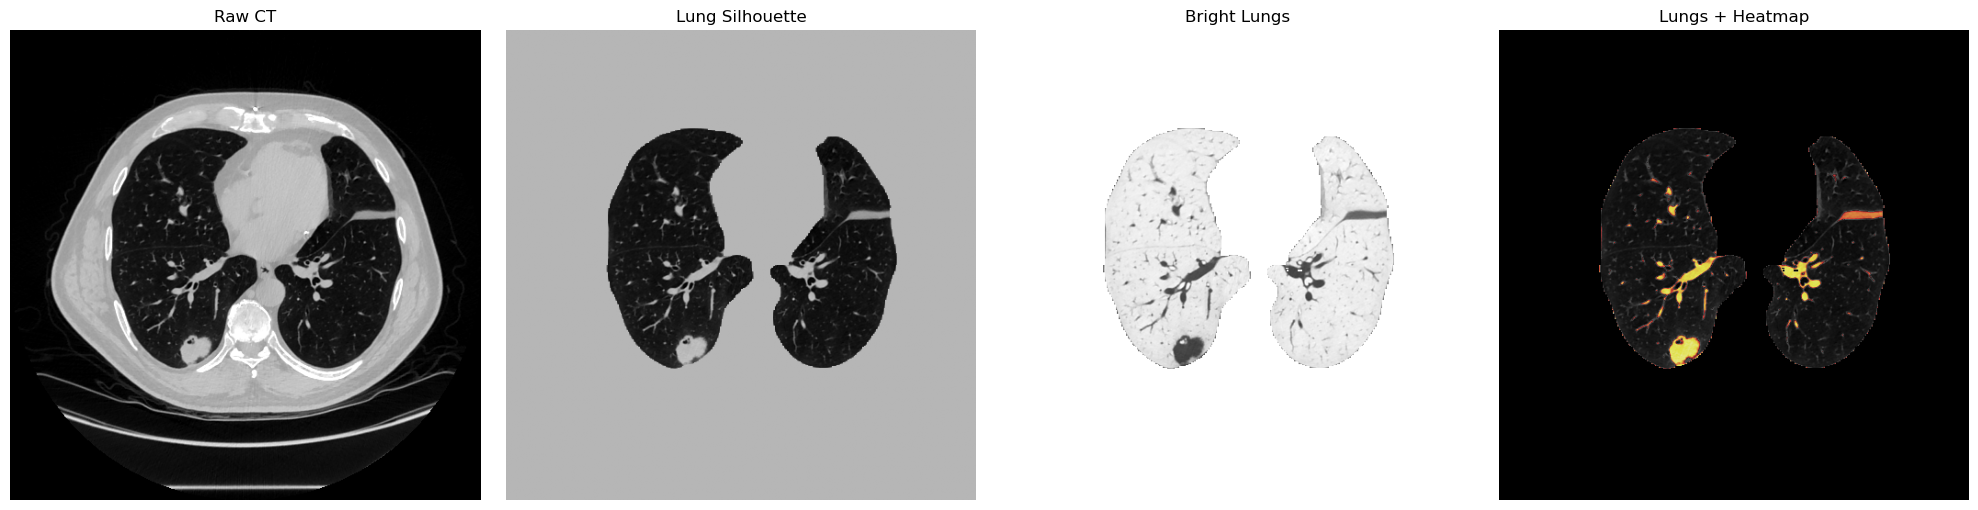

In [79]:
show_full_pipeline(volume, lung_mask, heatmap, idx=289)